<a href="https://www.kaggle.com/code/navneet0094/coral-data-alignment-jafee?scriptVersionId=332024695" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from skimage.feature import hog

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_preprocess

from tensorflow.keras.models import Model

sns.set_style("whitegrid")


2026-07-02 06:45:42.976904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782974743.419332      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782974743.545329      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782974744.593416      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782974744.593467      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782974744.593470      23 computation_placer.cc:177] computation placer alr

In [3]:
# Emotion Label Mapping
emotion_map = {
    "AN": 0,
    "DI": 1,
    "FE": 2,
    "HA": 3,
    "SA": 4,
    "SU": 5
}

emotion_names = [
    "Anger",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise"
]

In [4]:
def load_jaffe(dataset_path):

    data = []
    labels = []

    for img_name in sorted(os.listdir(dataset_path)):

        img_path = os.path.join(dataset_path, img_name)

        try:

            emotion = img_name.split(".")[1][:2]

            if emotion == "NE":
                continue

            img = Image.open(img_path).convert("L")
            img = img.resize((128,128))

            img = np.array(img)

            data.append(img)
            labels.append(emotion_map[emotion])

        except Exception:
            continue

    return np.array(data), np.array(labels)

In [5]:
def load_ckplus(dataset_path):

    data = []
    labels = []

    selected = {
        "anger":0,
        "disgust":1,
        "fear":2,
        "happy":3,
        "sadness":4,
        "surprise":5
    }

    for emotion in sorted(os.listdir(dataset_path)):

        if emotion == "contempt":
            continue

        emotion_folder = os.path.join(dataset_path, emotion)

        for img_name in sorted(os.listdir(emotion_folder)):

            img_path = os.path.join(emotion_folder, img_name)

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None:
                continue

            img = cv2.resize(
                img,
                (128,128)
            )

            data.append(img)
            labels.append(selected[emotion])

    return np.array(data), np.array(labels)

In [6]:
JAFFE_PATH = "/kaggle/input/datasets/navneet0094/jaf-data/jaffe"

CK_PATH = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

In [7]:
# Load datasets
jaffe_data, jaffe_labels = load_jaffe(JAFFE_PATH)
ck_data, ck_labels = load_ckplus(CK_PATH)

print("JAFFE:", jaffe_data.shape, jaffe_labels.shape)
print("CK+ :", ck_data.shape, ck_labels.shape)

JAFFE: (183, 128, 128) (183,)
CK+ : (927, 128, 128) (927,)


In [8]:
print("JAFFE Distribution")
for i,name in enumerate(emotion_names):
    print(f"{name:<10} : {(jaffe_labels==i).sum()}")
print()
print("="*45)
print("CK+ Distribution")
for i,name in enumerate(emotion_names):
    print(f"{name:<10} : {(ck_labels==i).sum()}")

JAFFE Distribution
Anger      : 30
Disgust    : 29
Fear       : 32
Happy      : 31
Sad        : 31
Surprise   : 30

CK+ Distribution
Anger      : 135
Disgust    : 177
Fear       : 75
Happy      : 207
Sad        : 84
Surprise   : 249


In [9]:
summary = pd.DataFrame({
    "Dataset":["JAFFE","CK+"],
    "Images":[len(jaffe_data),len(ck_data)],
    "Classes":[len(np.unique(jaffe_labels)),len(np.unique(ck_labels))],
    "Image Size":["128×128","128×128"]
})

summary

,Dataset,Images,Classes,Image Size
0,JAFFE,183,6,128×128
1,CK+,927,6,128×128


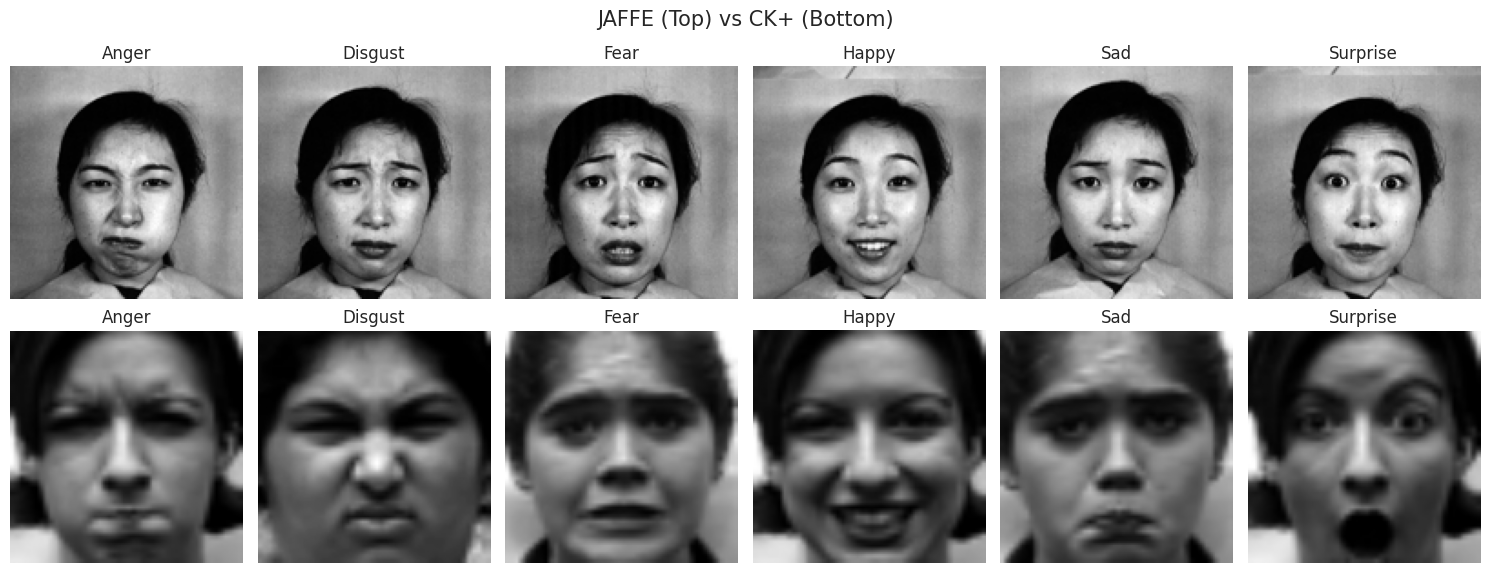

In [10]:
plt.figure(figsize=(15,6))
for i in range(6):
    plt.subplot(2,6,i+1)
    idx = np.where(jaffe_labels==i)[0][0]
    plt.imshow(jaffe_data[idx],cmap="gray")
    plt.title(emotion_names[i])
    plt.axis("off")

for i in range(6):
    plt.subplot(2,6,i+7)
    idx = np.where(ck_labels==i)[0][0]
    plt.imshow(ck_data[idx],cmap="gray")
    plt.title(emotion_names[i])
    plt.axis("off")
plt.suptitle("JAFFE (Top) vs CK+ (Bottom)",fontsize=15)

plt.tight_layout()

plt.show()


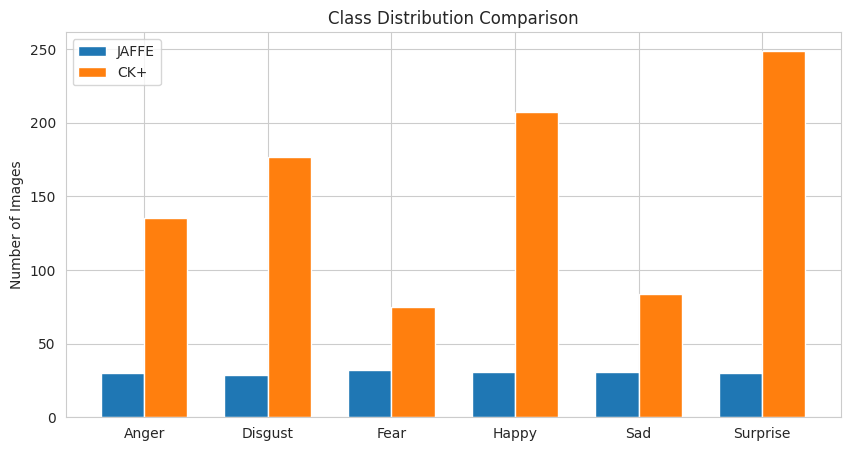

In [11]:
jaffe_counts = [(jaffe_labels==i).sum()for i in range(6)]
ck_counts = [(ck_labels==i).sum()for i in range(6)]
x = np.arange(6)
width = 0.35
plt.figure(figsize=(10,5))
plt.bar(
    x-width/2,
    jaffe_counts,
    width,
    label="JAFFE"
)
plt.bar(
    x+width/2,
    ck_counts,
    width,
    label="CK+"
)
plt.xticks(x,emotion_names)
plt.ylabel("Number of Images")
plt.title("Class Distribution Comparison")
plt.legend()
plt.show()

In [12]:
mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

vgg = VGG16(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
print("✓ MobileNetV2 Loaded")
print("✓ VGG16 Loaded")

/tmp/ipykernel_23/217322149.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
I0000 00:00:1782974778.866274      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782974778.872631      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ MobileNetV2 Loaded
✓ VGG16 Loaded


In [13]:
# Extract Handcrafted HOG Features
def extract_hog_features(images):
    features = []
    for img in images:
        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            feature_vector=True
        )
        features.append(hog_feature)
    return np.array(features)

In [14]:
X_hog_jaffe = extract_hog_features(jaffe_data)

X_hog_ck = extract_hog_features(ck_data)

print("JAFFE HOG :", X_hog_jaffe.shape)
print("CK+ HOG   :", X_hog_ck.shape)


JAFFE HOG : (183, 8100)
CK+ HOG   : (927, 8100)


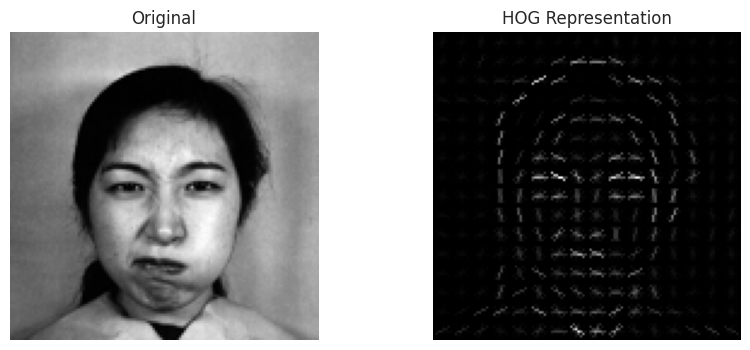

In [15]:
sample = jaffe_data[0]
feature, hog_image = hog(
    sample,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sample,cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(hog_image,cmap="gray")
plt.title("HOG Representation")
plt.axis("off")
plt.show()

In [16]:
def prepare_images(images, preprocess_function):
    processed = []
    for img in images:
        img = cv2.resize(img,(224,224))
        img = cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)
        img = preprocess_function(img)
        processed.append(img)
    return np.array(processed)

In [17]:
jaffe_mobile = prepare_images(jaffe_data,mobile_preprocess)

ck_mobile = prepare_images(ck_data,mobile_preprocess)

jaffe_vgg = prepare_images(jaffe_data,vgg_preprocess)

ck_vgg = prepare_images(ck_data,vgg_preprocess)

# print("Image preprocessing completed.")


In [18]:
X_mobile_jaffe = mobilenet.predict(jaffe_mobile,batch_size=32,verbose=1)
X_mobile_ck = mobilenet.predict(ck_mobile,batch_size=32,verbose=1)

print("JAFFE MobileNet :", X_mobile_jaffe.shape)
print("CK+ MobileNet   :", X_mobile_ck.shape)

I0000 00:00:1782974794.240914      72 service.cc:152] XLA service 0x7ce66c003100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782974794.240972      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782974794.240976      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782974794.998795      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-07-02 06:46:45.879104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 06:46:46.038402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 06:46:46.176351: E external/local_xl

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

2026-07-02 06:46:58.517955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 06:46:58.659287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

2026-07-02 06:47:11.457934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 06:47:11.596023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 06:47:11.733494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 423ms/step
JAFFE MobileNet : (183, 1280)
CK+ MobileNet   : (927, 1280)


In [19]:
X_vgg_jaffe = vgg.predict(jaffe_vgg,batch_size=32,verbose=1)
X_vgg_ck = vgg.predict(ck_vgg,batch_size=32,verbose=1)

print("JAFFE VGG :", X_vgg_jaffe.shape)
print("CK+ VGG   :", X_vgg_ck.shape)

6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 602ms/step
JAFFE VGG : (183, 512)
CK+ VGG   : (927, 512)


In [20]:
feature_summary = pd.DataFrame({
    "Feature":["HOG","MobileNetV2","VGG16"],
    "Dimension":[X_hog_jaffe.shape[1],X_mobile_jaffe.shape[1],X_vgg_jaffe.shape[1]]
})

feature_summary

,Feature,Dimension
0,HOG,8100
1,MobileNetV2,1280
2,VGG16,512


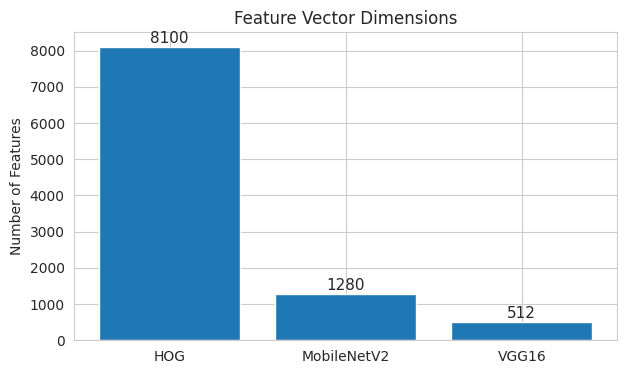

In [21]:
plt.figure(figsize=(7,4))

plt.bar(feature_summary["Feature"],feature_summary["Dimension"])
plt.title("Feature Vector Dimensions")
plt.ylabel("Number of Features")
for i,value in enumerate(feature_summary["Dimension"]):
    plt.text(i,
        value+100,str(value),ha="center",fontsize=11)
plt.show()

In [22]:
hog_scaler = StandardScaler()
mobile_scaler = StandardScaler()
vgg_scaler = StandardScaler()

In [23]:
X_hog_jaffe_scaled = hog_scaler.fit_transform(X_hog_jaffe)

X_hog_ck_scaled = hog_scaler.transform(X_hog_ck)

In [24]:
X_mobile_jaffe_scaled = mobile_scaler.fit_transform(X_mobile_jaffe)

X_mobile_ck_scaled = mobile_scaler.transform(X_mobile_ck)

In [25]:
X_vgg_jaffe_scaled = vgg_scaler.fit_transform(X_vgg_jaffe)

X_vgg_ck_scaled = vgg_scaler.transform(X_vgg_ck)

print("Scaling Completed")

Scaling Completed


In [26]:
X_train_fused = np.concatenate(
    [0.35 * X_hog_jaffe_scaled,0.35 * X_mobile_jaffe_scaled,0.30 * X_vgg_jaffe_scaled],
    axis=1
)

X_test_fused = np.concatenate(
    [0.35 * X_hog_ck_scaled,0.35 * X_mobile_ck_scaled,0.30 * X_vgg_ck_scaled],
    axis=1
)

print(X_train_fused.shape)
print(X_test_fused.shape)

(183, 9892)
(927, 9892)


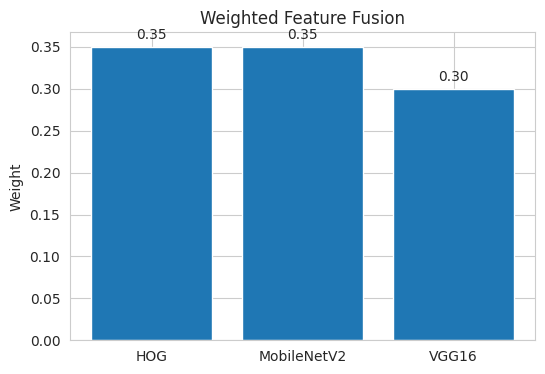

In [27]:
weights = pd.DataFrame({
    "Feature":["HOG","MobileNetV2","VGG16"],
    "Weight":[0.35,0.35,0.30]
})

plt.figure(figsize=(6,4))
bars = plt.bar(
    weights["Feature"],
    weights["Weight"]
)
plt.title("Weighted Feature Fusion")
plt.ylabel("Weight")
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.01,
        f"{bar.get_height():.2f}",
        ha='center')
plt.show()

In [28]:
pca = PCA(n_components=2,random_state=42)
combined = np.vstack([X_train_fused,X_test_fused])
combined_pca = pca.fit_transform(combined)

source_pca = combined_pca[:len(X_train_fused)]

target_pca = combined_pca[len(X_train_fused):]

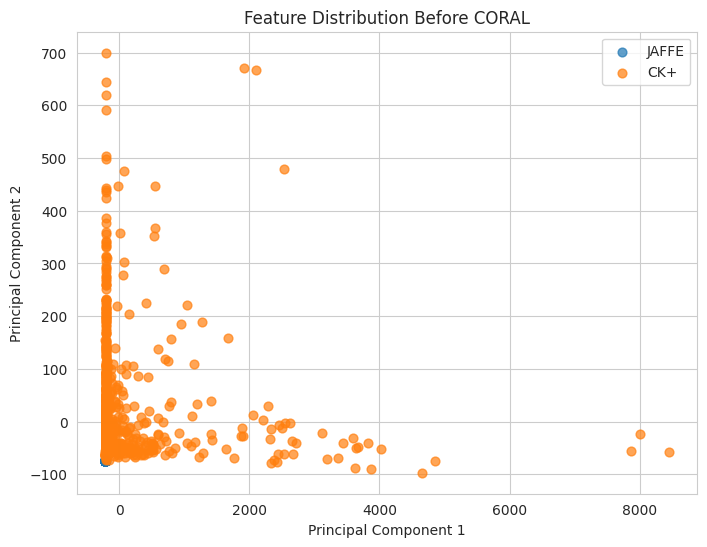

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(
    source_pca[:,0],
    source_pca[:,1],
    alpha=0.7,
    label="JAFFE",
    s=40
)

plt.scatter(
    target_pca[:,0],
    target_pca[:,1],
    alpha=0.7,
    label="CK+",
    s=40
)

plt.title("Feature Distribution Before CORAL")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [30]:
from sklearn.svm import SVC
svm = SVC(
    kernel="rbf",
    C=100,
    gamma="scale"
)
svm.fit(
    X_train_fused,
    jaffe_labels
)
print("Baseline SVM Trained")

Baseline SVM Trained


In [31]:
y_pred = svm.predict(X_test_fused)

In [32]:
acc = accuracy_score(ck_labels,y_pred)

f1 = f1_score(ck_labels,y_pred,average="macro")

print("Baseline Accuracy :",round(acc,4))

print("Baseline Macro F1 :",round(f1,4))

Baseline Accuracy : 0.1909
Baseline Macro F1 : 0.0534


In [33]:
print(classification_report(ck_labels,y_pred,target_names=emotion_names))

              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00       135
     Disgust       0.19      1.00      0.32       177
        Fear       0.00      0.00      0.00        75
       Happy       0.00      0.00      0.00       207
         Sad       0.00      0.00      0.00        84
    Surprise       0.00      0.00      0.00       249

    accuracy                           0.19       927
   macro avg       0.03      0.17      0.05       927
weighted avg       0.04      0.19      0.06       927



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


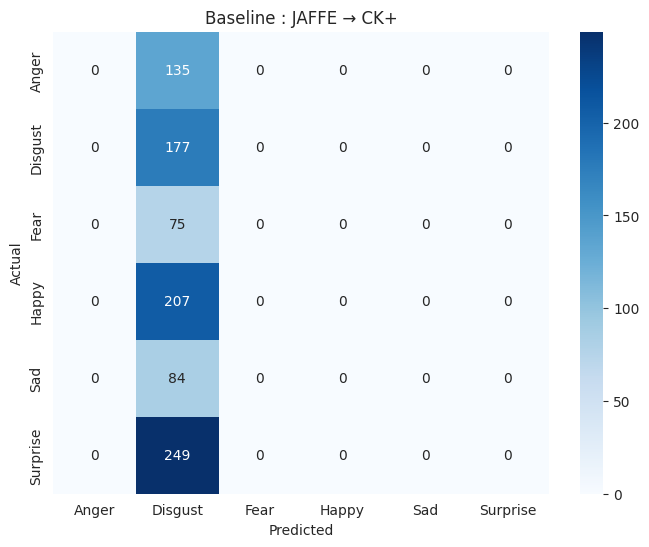

In [34]:
cm = confusion_matrix(ck_labels,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.title("Baseline : JAFFE → CK+")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
from sklearn.decomposition import PCA
# Keep 95% of variance
pca = PCA(
    n_components=0.95,
    random_state=42
)
X_train_pca = pca.fit_transform(X_train_fused)

X_test_pca = pca.transform(X_test_fused)

print("Original Feature Dimension :", X_train_fused.shape[1])
print("Reduced Feature Dimension  :", X_train_pca.shape[1])

Original Feature Dimension : 9892
Reduced Feature Dimension  : 146


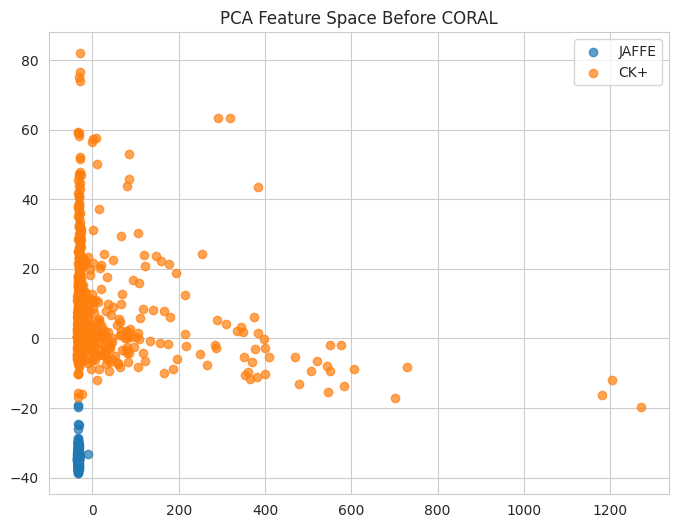

In [36]:
pca_vis = PCA(
    n_components=2,
    random_state=42
)
combined = np.vstack([
    X_train_pca,
    X_test_pca
])

combined_vis = pca_vis.fit_transform(combined)

source_vis = combined_vis[:len(X_train_pca)]
target_vis = combined_vis[len(X_train_pca):]

plt.figure(figsize=(8,6))
plt.scatter(
    source_vis[:,0],
    source_vis[:,1],
    label="JAFFE",
    alpha=0.7
)

plt.scatter(
    target_vis[:,0],
    target_vis[:,1],
    label="CK+",
    alpha=0.7
)

plt.title("PCA Feature Space Before CORAL")

plt.legend()

plt.show()

In [37]:
from scipy.linalg import fractional_matrix_power

def coral(source, target):

    # Center the data
    source_mean = np.mean(source, axis=0)
    target_mean = np.mean(target, axis=0)

    source_centered = source - source_mean
    target_centered = target - target_mean

    # Covariance matrices
    cov_source = np.cov(
        source_centered,
        rowvar=False
    ) + np.eye(source.shape[1])

    cov_target = np.cov(
        target_centered,
        rowvar=False
    ) + np.eye(target.shape[1])

    # Whitening source
    source_whiten = np.dot(
        source_centered,
        fractional_matrix_power(cov_source, -0.5)
    )

    # Coloring with target covariance
    source_aligned = np.dot(
        source_whiten,
        fractional_matrix_power(cov_target, 0.5)
    )

    # Add target mean
    source_aligned += target_mean

    return np.real(source_aligned)

In [38]:
X_train_coral = coral(
    X_train_pca,
    X_test_pca
)

print("CORAL Alignment Completed")

CORAL Alignment Completed


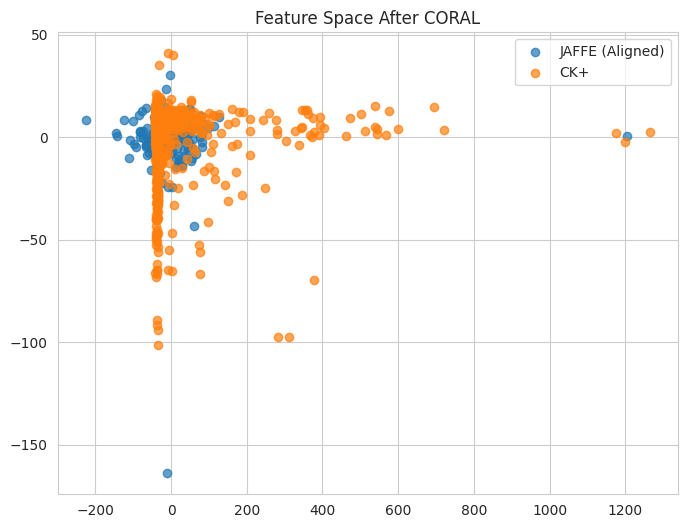

In [39]:
combined = np.vstack([
    X_train_coral,
    X_test_pca
])

combined_vis = pca_vis.fit_transform(combined)

source_vis = combined_vis[:len(X_train_coral)]
target_vis = combined_vis[len(X_train_coral):]

plt.figure(figsize=(8,6))

plt.scatter(
    source_vis[:,0],
    source_vis[:,1],
    label="JAFFE (Aligned)",
    alpha=0.7
)

plt.scatter(
    target_vis[:,0],
    target_vis[:,1],
    label="CK+",
    alpha=0.7
)

plt.title("Feature Space After CORAL")

plt.legend()

plt.show()

In [40]:
from sklearn.svm import SVC

svm_coral = SVC(
    kernel="rbf",
    C=100,
    gamma="scale"
)

svm_coral.fit(
    X_train_coral,
    jaffe_labels
)

print("CORAL SVM Trained")

CORAL SVM Trained


In [41]:
y_pred_coral = svm_coral.predict(
    X_test_pca
)

In [42]:
acc_coral = accuracy_score(
    ck_labels,
    y_pred_coral
)

f1_coral = f1_score(
    ck_labels,
    y_pred_coral,
    average="macro"
)

print("CORAL Accuracy :", round(acc_coral,4))
print("CORAL Macro F1 :", round(f1_coral,4))

CORAL Accuracy : 0.246
CORAL Macro F1 : 0.2268


In [43]:
print(
    classification_report(
        ck_labels,
        y_pred_coral,
        target_names=emotion_names
    )
)

              precision    recall  f1-score   support

       Anger       0.29      0.37      0.33       135
     Disgust       0.16      0.13      0.14       177
        Fear       0.11      0.27      0.16        75
       Happy       0.46      0.43      0.45       207
         Sad       0.07      0.11      0.08        84
    Surprise       0.36      0.14      0.21       249

    accuracy                           0.25       927
   macro avg       0.24      0.24      0.23       927
weighted avg       0.29      0.25      0.25       927



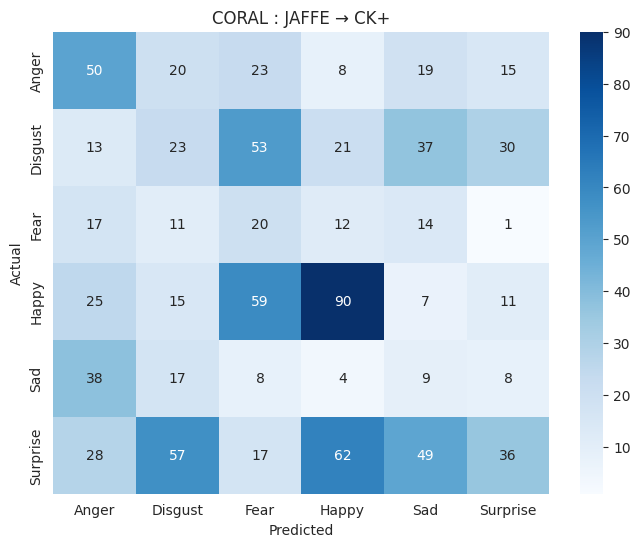

In [44]:
cm = confusion_matrix(
    ck_labels,
    y_pred_coral
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("CORAL : JAFFE → CK+")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()